# Sprint 2 - Limpeza, Tratamento, Split Temporal e EDA
Este notebook executa os Tópicos 1 e 2 detalhados no `Sprint2_TrilhaC.md`:
1. **Limpeza e Inspeção:** Verifica valores nulos, duplicatas e aplica regras de domínio (mantendo a pasta raw intocada).
2. **Split Temporal:** Divide os dados de 2015 a 2022 para Treino e 2023 a 2024 para Teste (Safra 2025 foi descartada pois a API do IBGE ainda não consolidou os dados).
3. **Análise Exploratória (EDA):** Realiza os gráficos requisitados APENAS sobre a base de Treino.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Garantir que a pasta interim existe
os.makedirs('../data/interim', exist_ok=True)

# Carregando os dados brutos da Sprint 1
df_raw = pd.read_csv('../data/raw/integrado.csv')

# Descartando a safra de 2025 conforme RFC (Dados do IBGE não consolidados)
df_raw = df_raw[df_raw['ano'] <= 2024]
display(df_raw.head())

,ano,area_plantada_ha,area_colhida_ha,quantidade_produzida_t,rendimento_kg_ha,PRECTOTCORR,T2M,T2M_MAX,T2M_MIN,RH2M,GWETROOT
0,2015,625900.0,619900.0,1951710.0,3148.0,645.49,27.850904,41.79,17.31,61.046274,0.635616
1,2016,620000.0,615000.0,1771200.0,2880.0,1147.75,26.832432,39.57,15.78,66.810902,0.658962
2,2017,620000.0,620000.0,2157600.0,3480.0,1561.12,25.576301,39.86,12.24,74.063096,0.714904
3,2018,600000.0,600000.0,2232000.0,3720.0,1903.15,25.089068,39.71,13.42,77.658548,0.755589
4,2019,605000.0,605000.0,2141700.0,3540.0,1210.35,26.609890,40.91,15.47,68.237671,0.675699


## 1.1 Inspeção e Limpeza

In [2]:
print("=== Estatística Descritiva (Raw) ===")
display(df_raw.describe())

print("\n=== Contagem de Nulos ===")
print(df_raw.isnull().sum())

print("\n=== Linhas Duplicadas ===")
print(df_raw.duplicated().sum())

=== Estatística Descritiva (Raw) ===


,ano,area_plantada_ha,area_colhida_ha,quantidade_produzida_t,rendimento_kg_ha,PRECTOTCORR,T2M,T2M_MAX,T2M_MIN,RH2M,GWETROOT
count,10.00000,10.000000,10.000000,1.000000e+01,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000
mean,2019.50000,606290.000000,604440.000000,2.099606e+06,3476.800000,1331.738000,26.250000,40.744000,13.846000,70.725443,0.692434
std,3.02765,11688.878855,10309.779608,1.547538e+05,293.318484,361.550451,0.859822,1.047878,2.348286,5.074774,0.037118
min,2015.00000,590000.000000,590000.000000,1.771200e+06,2880.000000,645.490000,25.089068,39.220000,8.740000,61.046274,0.635616
25%,2017.25000,598875.000000,598500.000000,2.029350e+06,3390.000000,1163.400000,25.656630,39.747500,12.775000,67.167594,0.663146
50%,2019.50000,602500.000000,599500.000000,2.130195e+06,3510.000000,1359.970000,26.290738,41.080000,14.245000,71.355178,0.693726
75%,2021.75000,616250.000000,612500.000000,2.213400e+06,3675.000000,1550.352500,26.782601,41.555000,15.215000,74.581993,0.712781
max,2024.00000,625900.000000,620000.000000,2.283300e+06,3870.000000,1903.150000,27.850904,42.030000,17.310000,77.658548,0.755589



=== Contagem de Nulos ===
ano                       0
area_plantada_ha          0
area_colhida_ha           0
quantidade_produzida_t    0
rendimento_kg_ha          0
PRECTOTCORR               0
T2M                       0
T2M_MAX                   0
T2M_MIN                   0
RH2M                      0
GWETROOT                  0
dtype: int64

=== Linhas Duplicadas ===
0


**Diagnóstico do Grupo:** Conforme observado acima, nossa base integrada veio limpa da Etapa de Coleta (sem nulos e sem duplicatas), pois o tratamento primário de sentinelas (-999) já foi mapeado no momento da integração do IBGE e NASA na Sprint 1. E a safra de 2025 foi removida conforme acordado.

In [3]:
df_limpo = df_raw.copy()

# Salvar em data/interim
df_limpo.to_csv('../data/interim/limpo.csv', index=False)
print("Dados limpos salvos em: ../data/interim/limpo.csv")

Dados limpos salvos em: ../data/interim/limpo.csv


## 2. Divisão entre Treino e Teste (Split Temporal)
Para evitar *Data Leakage* temporal, vamos separar:
- **Treino:** 2015 a 2022
- **Teste:** 2023 a 2024

In [4]:
df_treino = df_limpo[df_limpo['ano'] <= 2022].copy()
df_teste = df_limpo[df_limpo['ano'] >= 2023].copy()

print(f"Linhas no Treino: {df_treino.shape[0]} (Anos: {df_treino['ano'].min()} a {df_treino['ano'].max()})")
print(f"Linhas no Teste: {df_teste.shape[0]} (Anos: {df_teste['ano'].min()} a {df_teste['ano'].max()})")

Linhas no Treino: 8 (Anos: 2015 a 2022)
Linhas no Teste: 2 (Anos: 2023 a 2024)


## 4. Análise Exploratória de Dados (EDA) - Apenas no Treino!

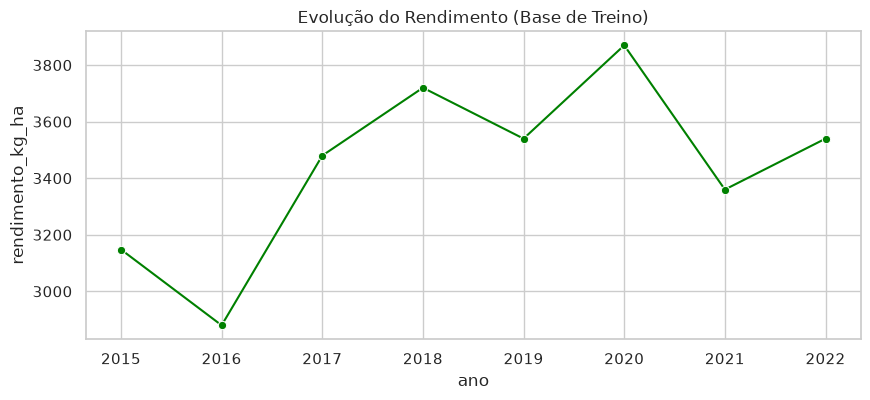

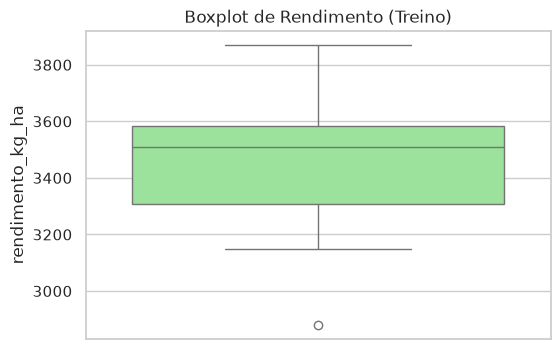

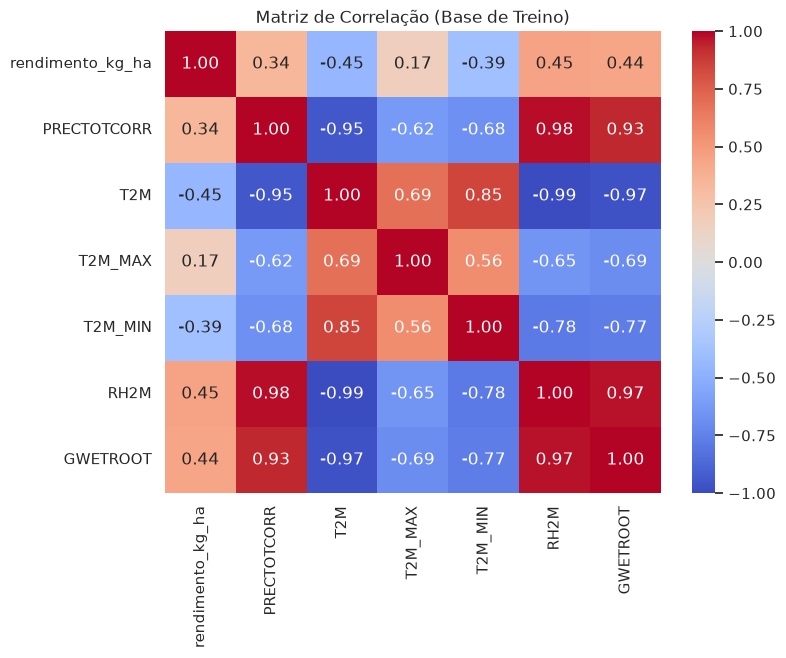

In [5]:
sns.set_theme(style="whitegrid")

# 1. Evolução da Produtividade (Treino)
plt.figure(figsize=(10, 4))
sns.lineplot(data=df_treino, x='ano', y='rendimento_kg_ha', marker='o', color='green')
plt.title('Evolução do Rendimento (Base de Treino)')
plt.xticks(df_treino['ano'])
plt.show()

# 2. Boxplot para encontrar Outliers
plt.figure(figsize=(6, 4))
sns.boxplot(y=df_treino['rendimento_kg_ha'], color='lightgreen')
plt.title('Boxplot de Rendimento (Treino)')
plt.show()

# 3. Matriz de Correlação das Features Climáticas x Rendimento
colunas_corr = ['rendimento_kg_ha', 'PRECTOTCORR', 'T2M', 'T2M_MAX', 'T2M_MIN', 'RH2M', 'GWETROOT']
plt.figure(figsize=(8, 6))
sns.heatmap(df_treino[colunas_corr].corr(), annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('Matriz de Correlação (Base de Treino)')
plt.show()